[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Thesis/blob/main/Model.ipynb)

# Librerie

In [1]:
!pip install obspy
!git clone https://github.com/Mpinaz/Thesis.git

fatal: destination path 'Thesis' already exists and is not an empty directory.


In [2]:
from obspy import read, Stream, UTCDateTime
from scipy.signal import stft

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from tqdm import tqdm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score, classification_report, f1_score

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px

import numpy as np
import pickle as pk
import copy
from collections import Counter, defaultdict
import pandas as pd

rng = np.random.default_rng(42)
rng_torch = torch.Generator().manual_seed(42)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preparing Dataset

In [4]:
catalog = pd.read_csv('/content/Thesis/Catalog.csv')

catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")
catalog["time"] = pd.to_datetime(catalog["time"], format="ISO8601", utc=True)

print(f"Loaded {len(catalog)} events")
catalog.head()

Loaded 11207 events


,time,lat,lon,depth_km,mag,FI_S
index,,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42,-100.000
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01,-100.000
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97,-0.481
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96,-0.559
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86,-0.666


In [5]:
with open("/content/drive/MyDrive/Datasets/True_Pre_Events.pkl", "rb") as f:
    pre = pk.load(f)
PRE_set = {E for St, E, Reg in pre}
print(f"{len(pre)} Samples Pre-Eruption")

with open("/content/drive/MyDrive/Datasets/True_Post_Events.pkl", "rb") as f:
    post = pk.load(f)
POST_set = {E for St, E, Reg in post}
print(f"{len(post)} Samples Co-Eruption")

112583 Samples Pre-Eruption
6440 Samples Co-Eruption


In [6]:
t = pd.to_datetime(catalog["time"], format="ISO8601")
tz = t.dt.tz
def ts(s):
    return pd.Timestamp(s, tz=tz)

mask = (
    ((t >= ts("2015-12-04")) & (t <= ts("2016-02-15"))) |
    ((t >= ts("2016-02-25")) & (t <  ts("2016-04-03"))))

Unrest = set(catalog.index[mask].tolist())

In [7]:
per_evento = defaultdict(list)
for St, E, Reg in pre:
    per_evento[E].append((St, E, Reg))

eventi = list(per_evento.keys())


rng.shuffle(eventi)


Data = []
eventi_usati = []
n = len(post)

for i , E in enumerate(eventi):
    if len(Data) >= n * 2:
        break

    if E not in Unrest:
      Data.extend(per_evento[E])
      eventi_usati.append(E)

Events = Data + post

print(f"Registrazioni Totali: {len(Events)}\nDati Pre Eruzione: {len(Data)}\nDati Post Eruzione {len(post)}")

Registrazioni Totali: 19322
Dati Pre Eruzione: 12882
Dati Post Eruzione 6440


In [8]:
X = np.arange(len(Events))
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])

groups_ev = np.array([E for (St, E, D) in Events])

def split_per_gruppo(groups):
    Train_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    tr, tmp = next(Train_Test_Shuffle.split(X, y, groups))

    Val_Test_Shuffle = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
    v, te = next(Val_Test_Shuffle.split(X[tmp], y[tmp], groups[tmp]))
    val, test = tmp[v], tmp[te]
    return tr, val, test

train_idx, val_idx, test_idx = split_per_gruppo(groups_ev)

# recupero dati
train = [Events[i] for i in train_idx]
val   = [Events[i] for i in val_idx]
test  = [Events[i] for i in test_idx]

In [9]:
assert set(groups_ev[train_idx]).isdisjoint(groups_ev[val_idx])
assert set(groups_ev[train_idx]).isdisjoint(groups_ev[test_idx])
assert set(groups_ev[val_idx]).isdisjoint(groups_ev[test_idx])

groups_ev = groups_ev[(groups_ev != 'Event 11208') & (groups_ev != 'Event 11209')]

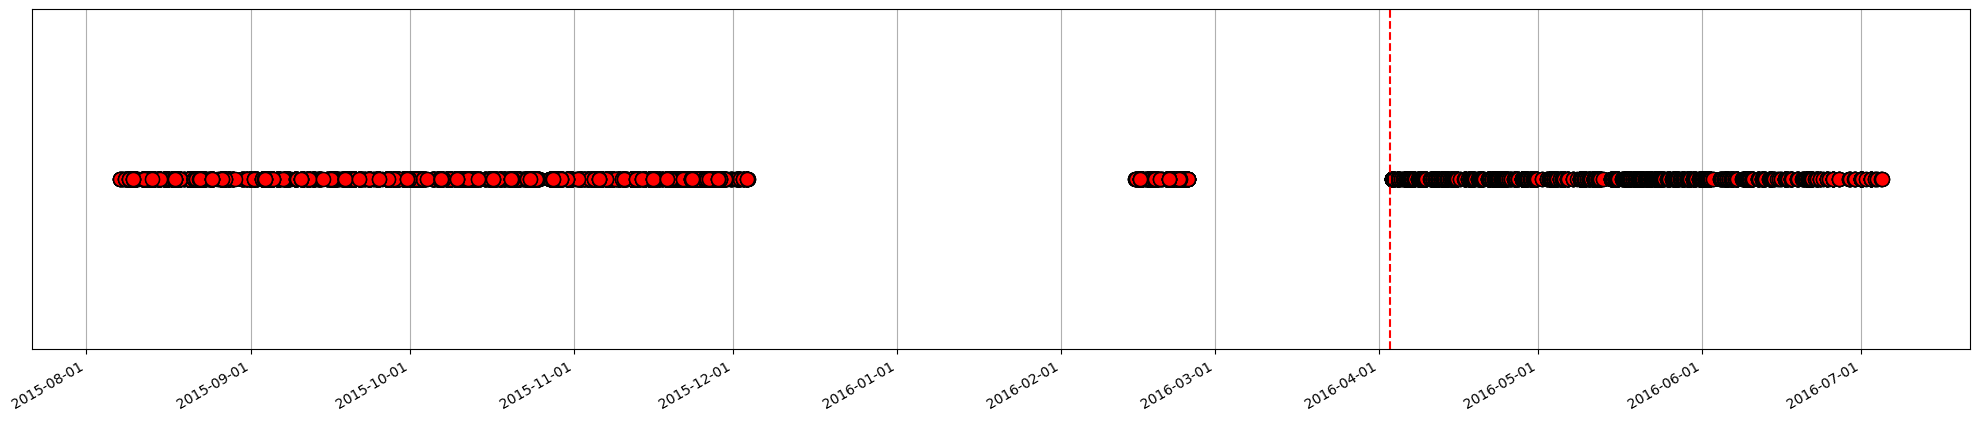

In [10]:
tempi = pd.to_datetime(catalog.loc[groups_ev, "time"], format="ISO8601")

fig, ax = plt.subplots(figsize=(25, 5))
ax.plot(tempi.values, [0]*len(tempi), "o", color="red", ms=10,
        markeredgecolor="black", markeredgewidth=1)
ax.yaxis.set_visible(False)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.axvline(pd.Timestamp("2016-04-03", tz="UTC"), color="red", linestyle="--")
ax.grid(True)
fig.autofmt_xdate()
plt.show()

train: Eventi Post = 5037, Eventi Pre = 10264, Proporzione eventi post = 0.329
val: Eventi Post = 597, Eventi Pre = 1414, Proporzione eventi post = 0.297
test: Eventi Post = 806, Eventi Pre = 1204, Proporzione eventi post = 0.401


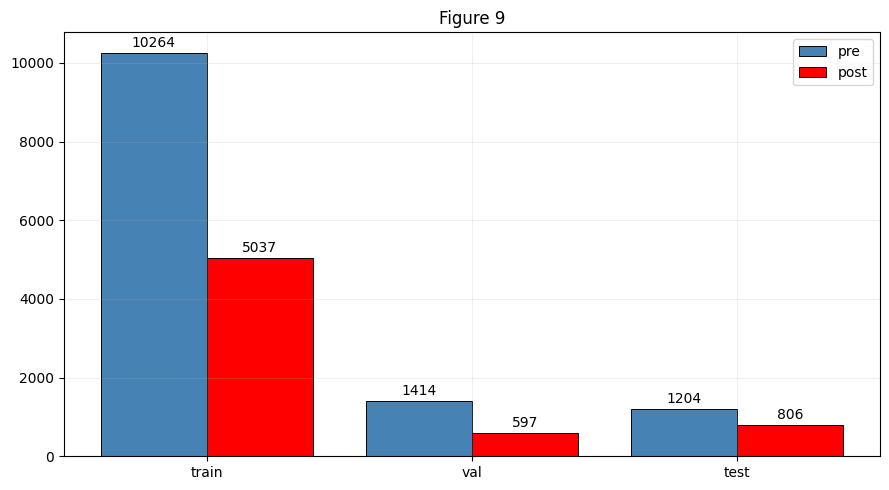

In [11]:
fig2, ax = plt.subplots(figsize=(9, 5))
w = 0.4

for i, (nome, idx) in enumerate([("train", train_idx), ("val", val_idx), ("test", test_idx)]):
    lab = y[idx]
    n_post = int(lab.sum())
    n_pre  = int(len(lab) - lab.sum())
    print(f"{nome}: Eventi Post = {n_post}, Eventi Pre = {n_pre}, Proporzione eventi post = {lab.mean():.3f}")

    b1 = ax.bar(i - w/2, n_pre,  w, color="steelblue", label="pre"  if i == 0 else None, edgecolor="black", linewidth=0.7)
    b2 = ax.bar(i + w/2, n_post, w, color="red",       label="post" if i == 0 else None, edgecolor="black", linewidth=0.7)
    ax.bar_label(b1, padding=2)
    ax.bar_label(b2, padding=2)

ax.set_xticks(range(3))
ax.set_xticklabels(["train", "val", "test"])
ax.set_title("Figure 9")
ax.legend()
ax.grid("on", alpha = 0.2)

fig2.tight_layout()
# fig2.savefig("Figure 9 (Train/Val/Test Splits).png", dpi=150)
plt.show()

# CNN1D

In [12]:
class WaveDataset(Dataset):
    def __init__(self, events, labels, target_len=1000):
        self.events = events
        self.labels = labels
        self.target_len = target_len

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]
        arr = np.stack([tr.data[:self.target_len] for tr in D]).astype(np.float32)

        # normalizzazione per traccia
        arr = arr - arr.mean(axis=1, keepdims=True)
        std = arr.std(axis=1, keepdims=True)
        arr = arr / (std + 1e-8)

        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [13]:
train_ds_W = WaveDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_W   = WaveDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_W  = WaveDataset([Events[i] for i in test_idx],  y[test_idx])


train_loader_Wave = DataLoader(train_ds_W, batch_size=32, shuffle=True, generator = rng_torch) # Togliere Generator per randomness
val_loader_Wave   = DataLoader(val_ds_W,   batch_size=32)
test_loader_Wave  = DataLoader(test_ds_W,  batch_size=32)

In [14]:
class CNN(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.15
        self.features = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(2),
            nn.ReLU(),

            nn.Dropout(self.p),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(2),
            nn.ReLU(),


            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
OneD_model = CNN().to(device)

class_weights = torch.tensor([1.0, 2.0], device=device)
crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
opt = optim.Adam(OneD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

In [16]:
history1D = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}
best_val_bacc = 0.0
best_state = None


pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    OneD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Wave:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = OneD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation

    OneD_model.eval()
    tot_loss, total = 0.0, 0
    val_true, val_pred = [], []
    with torch.no_grad():
        for x, y in val_loader_Wave:
            x, y = x.to(device), y.to(device)
            out = OneD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            total    += x.size(0)
            val_true.append(y.cpu())
            val_pred.append(out.argmax(1).cpu())

    val_loss = tot_loss / total
    val_true = torch.cat(val_true).numpy()
    val_pred = torch.cat(val_pred).numpy()
    val_acc  = (val_true == val_pred).mean()
    val_bacc = balanced_accuracy_score(val_true, val_pred)
    val_f1p  = f1_score(val_true, val_pred, pos_label=1)

    scheduler.step(val_loss)   # da attivare con lo scheduler

    history1D["train_loss"].append(train_loss)
    history1D["val_loss"].append(val_loss)
    history1D["train_acc"].append(train_acc)
    history1D["val_acc"].append(val_acc)
    history1D["val_bacc"].append(val_bacc)
    history1D["val_f1p"].append(val_f1p)

    if not (epoch + 1) % 25:
          tqdm.write(f"\nEpoch {epoch+1}\ntrain_acc={train_acc:.4f} | val_acc={val_acc:.3f} | val_bacc={val_bacc:.3f} | val_f1p={val_f1p:.3f}")

    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state = copy.deepcopy(OneD_model.state_dict())

OneD_model.load_state_dict(best_state)
print(f"Best val balanced accuracy: {best_val_bacc:.4f}")

Training:  25%|██▌       | 25/100 [01:59<05:49,  4.66s/it]


Epoch 25
train_acc=0.8533 | val_acc=0.776 | val_bacc=0.826 | val_f1p=0.716


Training:  50%|█████     | 50/100 [03:57<03:58,  4.76s/it]


Epoch 50
train_acc=0.9082 | val_acc=0.889 | val_bacc=0.876 | val_f1p=0.818


Training:  75%|███████▌  | 75/100 [05:54<01:59,  4.77s/it]


Epoch 75
train_acc=0.9288 | val_acc=0.900 | val_bacc=0.882 | val_f1p=0.832


Training: 100%|██████████| 100/100 [07:54<00:00,  4.74s/it]


Epoch 100
train_acc=0.9412 | val_acc=0.888 | val_bacc=0.874 | val_f1p=0.817
Best val balanced accuracy: 0.8896


# CNN2D

In [17]:
class SpecDataset(Dataset):
    def __init__(self, events, labels):
        self.events = events
        self.labels = labels

    def __len__(self):
        return len(self.events)

    def __getitem__(self, i):
        St, E, D = self.events[i]

        specs = []
        for tr in D:
            sig = tr.data[:1000]
            _, _, Zxx = stft(sig, fs=50, nperseg=64, noverlap=48)
            S = np.log1p(np.abs(Zxx))
            S = (S - S.mean()) / (S.std() + 1e-8)
            specs.append(S)

        arr = np.stack(specs).astype(np.float32)
        x = torch.from_numpy(arr)
        y = torch.tensor(self.labels[i], dtype=torch.long)
        return x, y

In [18]:
y = np.array([1 if E in POST_set else 0 for (St, E, D) in Events])
train_ds_S = SpecDataset([Events[i] for i in train_idx], y[train_idx])
val_ds_S   = SpecDataset([Events[i] for i in val_idx],   y[val_idx])
test_ds_S  = SpecDataset([Events[i] for i in test_idx],  y[test_idx])

train_loader_Spec = DataLoader(train_ds_S, batch_size=32, shuffle=True)
val_loader_Spec   = DataLoader(val_ds_S,   batch_size=32)
test_loader_Spec  = DataLoader(test_ds_S,  batch_size=32)

In [19]:
class CNN2D(nn.Module):
    def __init__(self, input_channels=3, output_classes=2):
        super().__init__()
        self.p = 0.15
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.ReLU(),

            nn.Dropout2d(self.p),

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.ReLU(),

            # nn.Dropout2d(self.p),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            # nn.MaxPool2d(2),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )
        self.lin = nn.Linear(256, output_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.lin(x)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Epochs = 100
TwoD_model = CNN2D().to(device)

weights = torch.tensor([1.0, 2.0], device=device)
crit = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
opt = optim.Adam(TwoD_model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=8e-5)

In [21]:
history2D = {"train_loss": [], "val_loss": [],
             "train_acc": [], "val_acc": [],
             "val_bacc": [], "val_f1p": []}

best_val_bacc = 0.0
best_state = None

pbar = tqdm(range(Epochs), desc="Training")
for epoch in pbar:
    TwoD_model.train()
    tot_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader_Spec:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = TwoD_model(x)
        loss = crit(out, y)
        loss.backward()
        opt.step()

        tot_loss += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    train_loss = tot_loss / total
    train_acc  = correct / total

    # Validation
    TwoD_model.eval()
    tot_loss, total = 0.0, 0
    val_true, val_pred = [], []
    with torch.no_grad():
        for x, y in val_loader_Spec:
            x, y = x.to(device), y.to(device)
            out = TwoD_model(x)
            loss = crit(out, y)

            tot_loss += loss.item() * x.size(0)
            total    += x.size(0)
            val_true.append(y.cpu())
            val_pred.append(out.argmax(1).cpu())

    val_loss = tot_loss / total
    val_true = torch.cat(val_true).numpy()
    val_pred = torch.cat(val_pred).numpy()
    val_acc  = (val_true == val_pred).mean()
    val_bacc = balanced_accuracy_score(val_true, val_pred)
    val_f1p  = f1_score(val_true, val_pred, pos_label=1)

    scheduler.step(val_loss)

    history2D["train_loss"].append(train_loss)
    history2D["val_loss"].append(val_loss)
    history2D["train_acc"].append(train_acc)
    history2D["val_acc"].append(val_acc)
    history2D["val_bacc"].append(val_bacc)
    history2D["val_f1p"].append(val_f1p)

    if not (epoch + 1) % 25:
        tqdm.write(f"\nEpoch {epoch+1}\ntrain_acc={train_acc:.4f} | val_acc={val_acc:.3f} | val_bacc={val_bacc:.3f} | val_f1p={val_f1p:.3f}")

    if val_bacc > best_val_bacc:
        best_val_bacc = val_bacc
        best_state = copy.deepcopy(TwoD_model.state_dict())

TwoD_model.load_state_dict(best_state)
print(f"\nBest val balanced accuracy: {best_val_bacc:.4f}")

Training:  25%|██▌       | 25/100 [12:13<36:13, 28.98s/it]


Epoch 25
train_acc=0.9559 | val_acc=0.937 | val_bacc=0.949 | val_f1p=0.902


Training:  50%|█████     | 50/100 [24:20<23:59, 28.78s/it]


Epoch 50
train_acc=0.9936 | val_acc=0.955 | val_bacc=0.961 | val_f1p=0.927


Training:  75%|███████▌  | 75/100 [36:16<11:48, 28.34s/it]


Epoch 75
train_acc=0.9994 | val_acc=0.964 | val_bacc=0.962 | val_f1p=0.941


Training: 100%|██████████| 100/100 [48:17<00:00, 28.97s/it]


Epoch 100
train_acc=0.9993 | val_acc=0.959 | val_bacc=0.962 | val_f1p=0.934

Best val balanced accuracy: 0.9648


# Results Plots

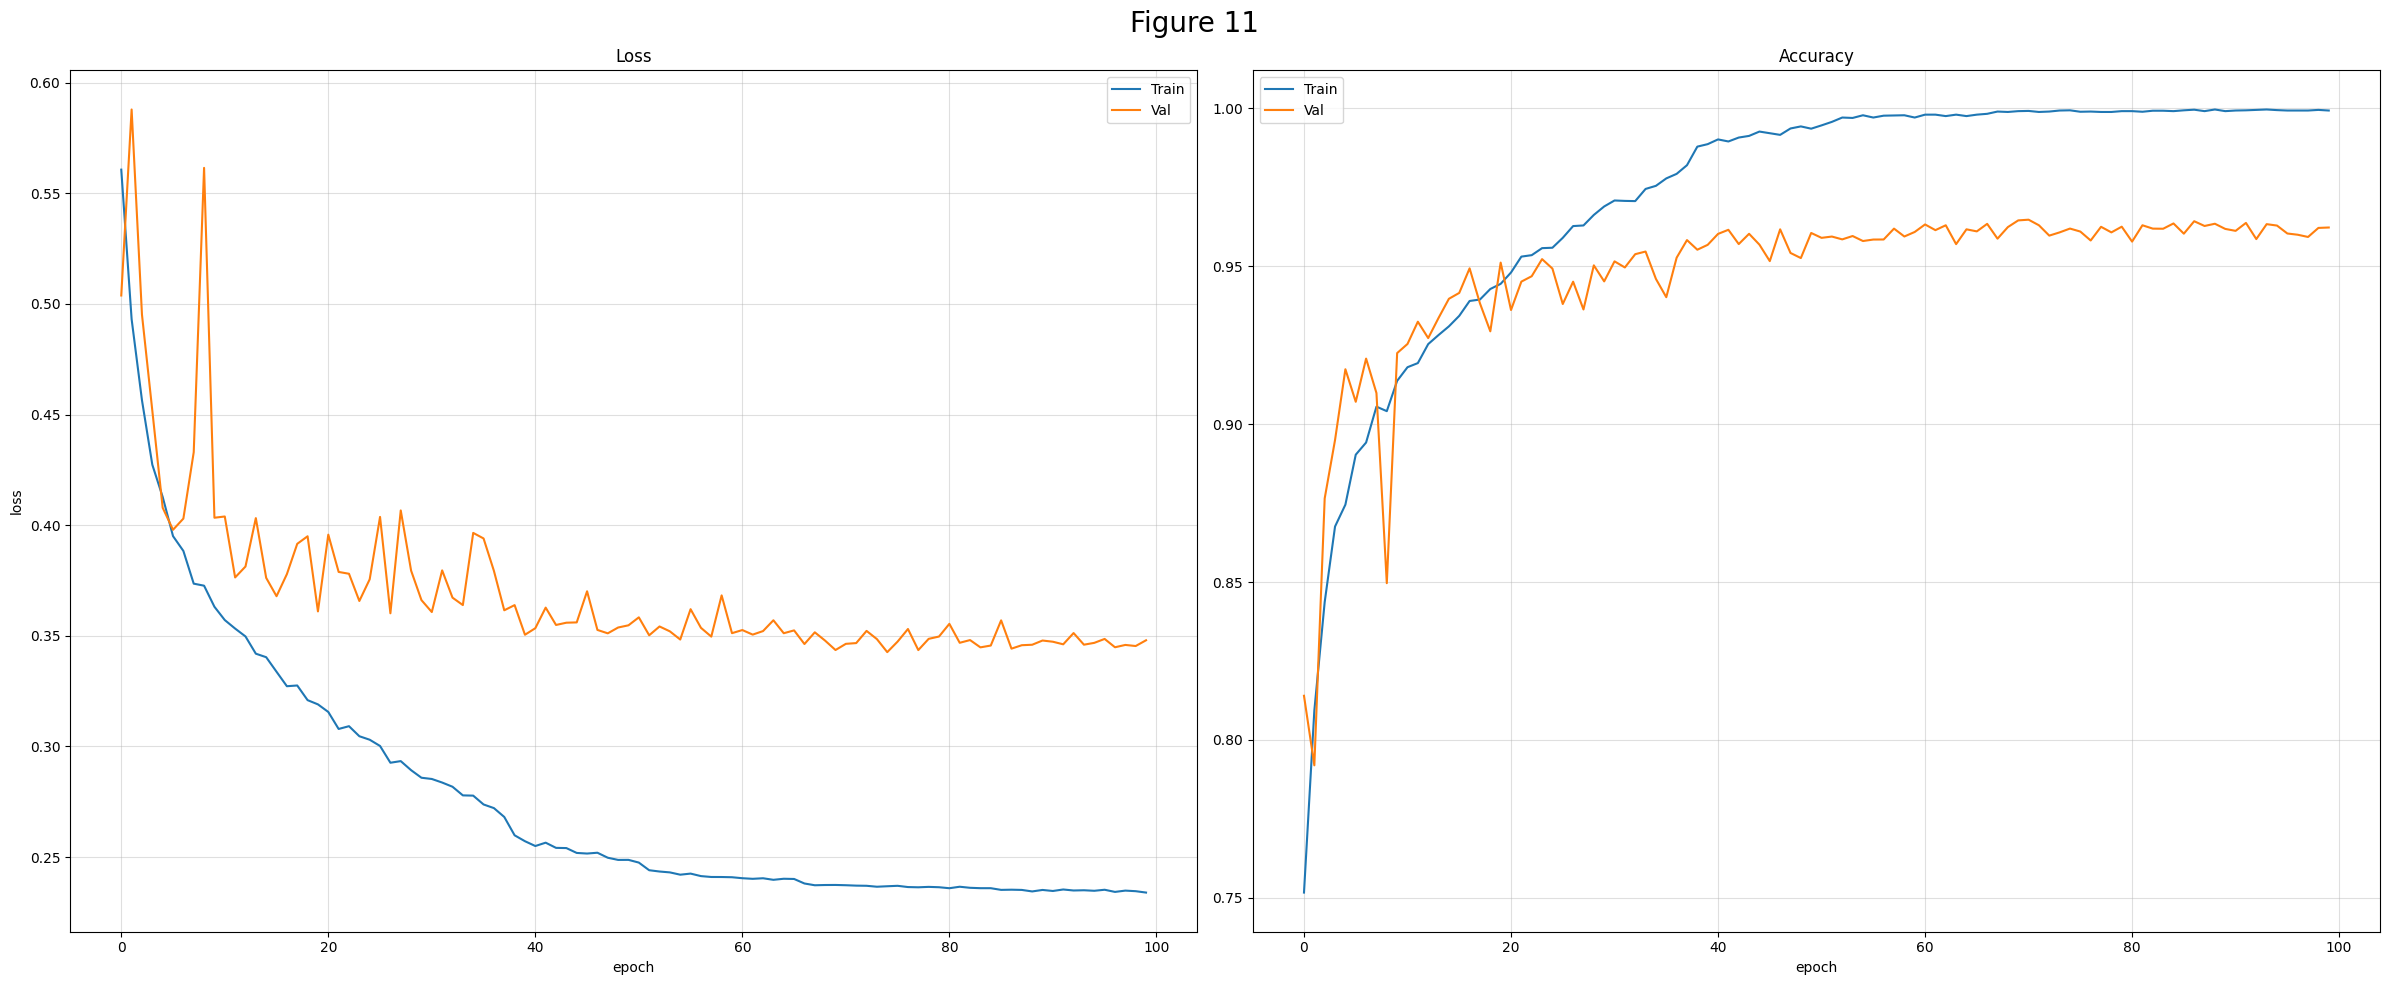

In [46]:
# history, Using, model = history1D, "CNN1D", OneD_model

history, Using, model= history2D, "CNN2D", TwoD_model

fig, ax = plt.subplots(1, 2, figsize=(24, 10))

ax[0].plot(history["train_loss"], label="Train")
ax[0].plot(history["val_loss"],   label="Val")
ax[0].set_title("Loss")
ax[0].legend()
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].grid(alpha = 0.4)

ax[1].plot(history["train_acc"], label="Train")
ax[1].plot(history["val_bacc"], label="Val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")
ax[1].grid(alpha = 0.4)
ax[1].legend()

fig.suptitle("Figure 11", fontsize=20)
fig.tight_layout()
fig.savefig(f"Figure 11 (1DCNN Loss and Accuracy over epochs).png", dpi=150, bbox_inches="tight")
plt.show()

In [47]:
def get_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            out = model(x.to(device))
            y_pred.extend(out.argmax(1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

In [48]:
model.eval()

tst = test_loader_Wave if Using == "CNN1D" else test_loader_Spec
yt, yp = get_preds(model, tst)

print(classification_report(yt, yp, target_names=["pre","post"], digits=3))

              precision    recall  f1-score   support

         pre      0.968     0.944     0.956      1204
        post      0.919     0.954     0.936       806

    accuracy                          0.948      2010
   macro avg      0.944     0.949     0.946      2010
weighted avg      0.949     0.948     0.948      2010



In [49]:
rep = classification_report(yt, yp, target_names=["pre", "post"],
                            digits=3, output_dict=True)

df_rep = pd.DataFrame(rep).transpose().round(3)
df_rep = df_rep.drop(index=["accuracy", "macro avg"])

bacc = balanced_accuracy_score(yt, yp)
print(f"Balanced Accuracy: {bacc:.3f}")

md = df_rep.to_markdown()
print(md)

Balanced Accuracy: 0.949
|              |   precision |   recall |   f1-score |   support |
|:-------------|------------:|---------:|-----------:|----------:|
| pre          |       0.968 |    0.944 |      0.956 |      1204 |
| post         |       0.919 |    0.954 |      0.936 |       806 |
| weighted avg |       0.949 |    0.948 |      0.948 |      2010 |


In [50]:
with open("1DCNN_report.md", "w") as f:
    f.write(df_rep.to_markdown())
    f.write(f"\n\n**Balanced accuracy:** {bacc:.3f}\n")

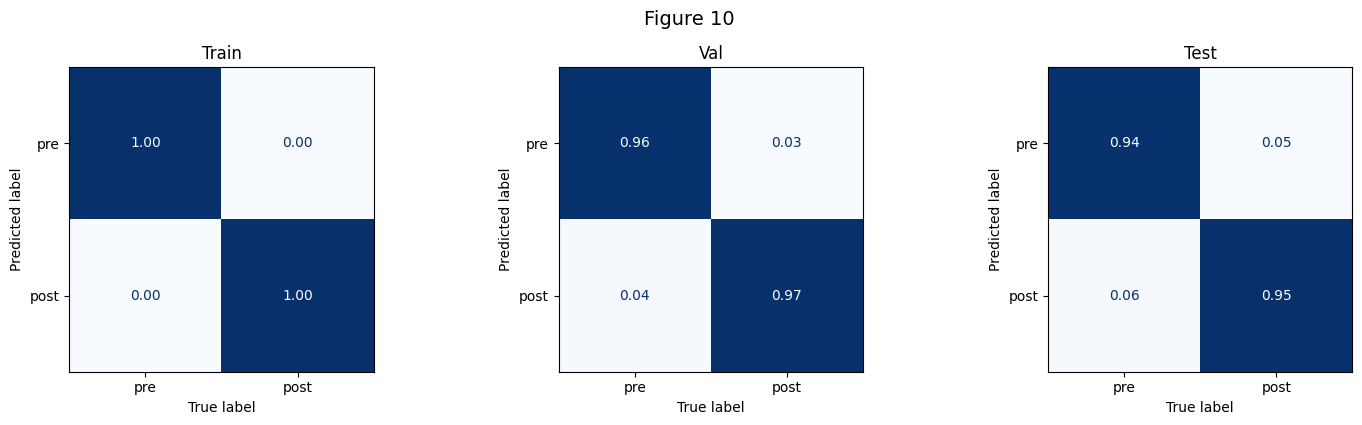

In [51]:
loaders = {"Train": train_loader_Spec, "Val": val_loader_Spec, "Test": test_loader_Spec} if Using == "CNN2D" else {"Train": train_loader_Wave, "Val": val_loader_Wave, "Test": test_loader_Wave}
labels  = ["pre", "post"]
model.eval()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, loader) in zip(axes, loaders.items()):
    yt, yp = get_preds(model, loader)
    cm = confusion_matrix(yt, yp, labels=[0, 1], normalize = "true")
    ConfusionMatrixDisplay(cm.T, display_labels=labels).plot(ax=ax, colorbar=False, cmap = "Blues", values_format=".2f")
    ax.set_xlabel("True label")
    ax.set_ylabel("Predicted label")
    ax.set_title(name)

fig.tight_layout()
fig.suptitle("Figure 10", fontsize=14, y=1.05)
fig.savefig(f"Figure 10 (1DCNN Confusion Matrices).png", dpi=150, bbox_inches="tight")
plt.show()

In [52]:
mis_idx = np.where(yt != yp)[0]
test_events = test_ds_W.events if Using == "CNN1D" else test_ds_S.events
eventi_test = [test_events[i][1] for i in range(len(test_events))]


tot_per_evento = Counter(eventi_test)
err_per_evento = Counter(test_events[i][1] for i in mis_idx)
Pre_Post_Row = ["post" if e in POST_set else "pre" for e in list(tot_per_evento.keys())]

df_err = pd.DataFrame({
    "evento": list(tot_per_evento.keys()),
    "Pre o Post" : Pre_Post_Row,
    "Registrazioni Totali": [tot_per_evento[e] for e in tot_per_evento],
    "Registrazioni Errate": [err_per_evento.get(e, 0) for e in tot_per_evento]})

df_err["Percentuale Errata"] = (df_err["Registrazioni Errate"] / df_err["Registrazioni Totali"] * 100).round(2)

df_err = df_err[df_err["Registrazioni Errate"] > 0].reset_index(drop=True)
df_err = df_err.sort_values(["Percentuale Errata"], ascending = False).reset_index(drop=True)
df_err.to_csv("Table 1 (1DCNN wrong classifications).csv")
df_err


,evento,Pre o Post,Registrazioni Totali,Registrazioni Errate,Percentuale Errata
0,Event 5370,pre,9,5,55.56
1,Event 8273,pre,18,10,55.56
2,Event 11004,post,8,3,37.50
3,Event 8513,pre,12,4,33.33
4,Event 4153,pre,6,2,33.33
5,Event 2592,pre,15,5,33.33
6,Event 5461,pre,19,6,31.58
7,Event 10983,post,7,2,28.57
8,Event 4169,pre,4,1,25.00
9,Event 11144,post,4,1,25.00


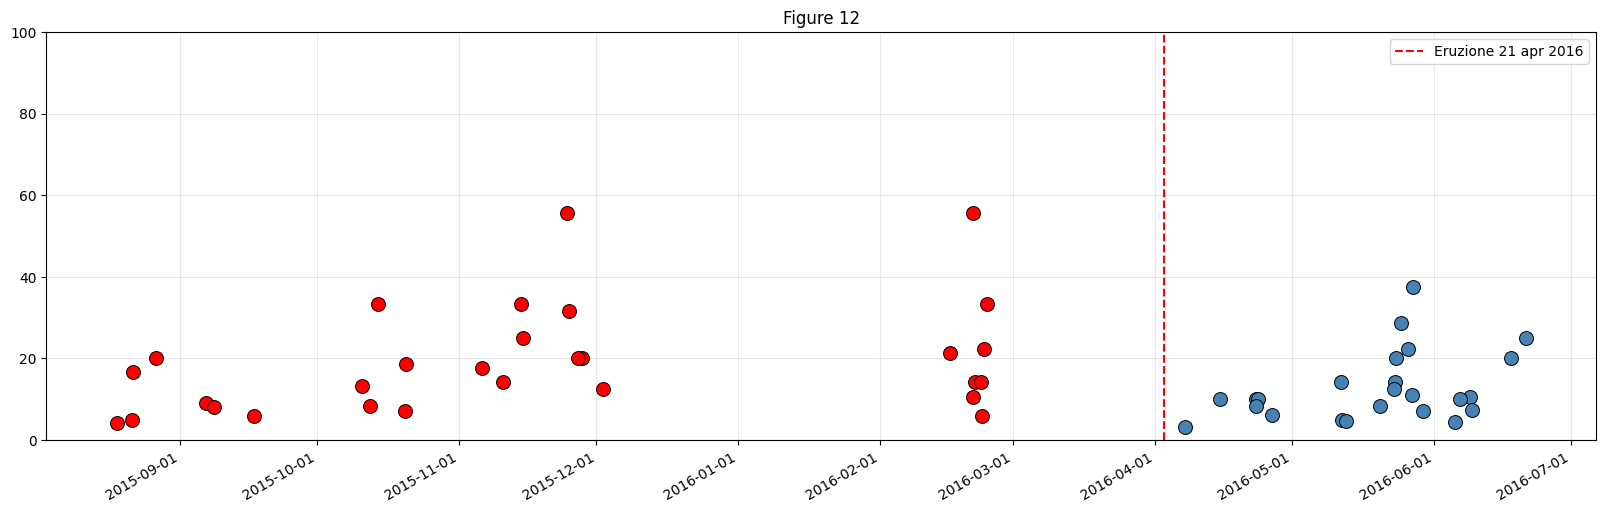

In [53]:
df_err["classe"] = df_err["evento"].apply(lambda e: 1 if e in POST_set else 0)
df_err["time"]   = df_err["evento"].map(catalog["time"])

# separo i due tipi di errore
pre_err  = df_err[df_err["classe"] == 0]   # Falsi Positivi  (pre invece di post)
post_err = df_err[df_err["classe"] == 1]   # Falsi Negativi  (post invece di pre)

fig, ax = plt.subplots(figsize=(20, 6))

# stem: l'altezza = percentuale di errore dell'evento

ax.plot(pre_err["time"], pre_err["Percentuale Errata"], "o",
        color="red", ms=10, markeredgecolor="black", markeredgewidth=0.7)

ax.plot(post_err["time"], post_err["Percentuale Errata"], "o",
        color="steelblue", ms=10, markeredgecolor="black", markeredgewidth=0.7)


ax.axvline(pd.Timestamp("2016-04-03", tz="UTC"), color="red", linestyle="--", linewidth=1.5, label="Eruzione 21 apr 2016")

ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.grid(alpha=0.3)
ax.legend()
ax.set_title(f"Figure 12")
fig.autofmt_xdate()
fig.savefig(f"Figure 12 (1DCNN Confidence for wrong classifications)", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
torch.save(OneD_model.state_dict(), "cnn1d.pth")